In [6]:
import sys
!{sys.executable} -m pip install seaborn pyarrow -q

In [7]:
import json
import pickle
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Resolve project root regardless of whether the notebook is run from
# the project root or the notebook/ subdirectory.
_HERE = Path().resolve()
_PROJECT_ROOT = _HERE.parent if (_HERE / "team_diagnosis.ipynb").exists() else _HERE

BASE_ARTIFACTS_DIR = _PROJECT_ROOT / "artifacts"
MODEL_ARTIFACTS_DIR = BASE_ARTIFACTS_DIR / "team_diagnosis"
OUTPUT_DIR = _PROJECT_ROOT / "notebook" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root   : {_PROJECT_ROOT}")
print(f"Artifacts root : {MODEL_ARTIFACTS_DIR.resolve()}")
print(f"Outputs        : {OUTPUT_DIR.resolve()}")

Project root   : C:\Users\Areen\Python\.venv\nfl-model-platform
Artifacts root : C:\Users\Areen\Python\.venv\nfl-model-platform\artifacts\team_diagnosis
Outputs        : C:\Users\Areen\Python\.venv\nfl-model-platform\notebook\outputs


In [8]:
def find_artifact_dirs(base_dir: Path = MODEL_ARTIFACTS_DIR) -> List[Path]:
    if not base_dir.exists():
        print(f"No artifacts directory found at {base_dir.resolve()}")
        return []
    runs: List[Path] = []
    for version_dir in sorted(base_dir.iterdir()):
        if version_dir.is_dir():
            runs.append(version_dir)
    return runs


def load_metadata(artifact_dir: Path) -> Optional[Dict]:
    meta_path = artifact_dir / "metadata.json"
    if not meta_path.exists():
        print(f"No metadata.json in {artifact_dir}")
        return None
    with meta_path.open() as f:
        meta = json.load(f)
    meta["artifact_dir"] = str(artifact_dir)
    meta.setdefault("version", artifact_dir.name)
    return meta


def load_ridge_model(artifact_dir: Path):
    """Load the RidgeCV expected-wins regressor."""
    path = artifact_dir / "model.pkl"
    if not path.exists():
        print(f"No model.pkl in {artifact_dir}")
        return None
    with path.open("rb") as f:
        return pickle.load(f)


def load_core_model(artifact_dir: Path):
    """Load the full TeamDiagnosticModel (unit z-scores, composites, rankings)."""
    path = artifact_dir / "core_model.pkl"
    if not path.exists():
        print(f"No core_model.pkl in {artifact_dir}")
        return None
    with path.open("rb") as f:
        return pickle.load(f)


def load_shap_values(artifact_dir: Path) -> Optional[pd.DataFrame]:
    path = artifact_dir / "shap_values.pkl"
    if not path.exists():
        print(f"No shap_values.pkl in {artifact_dir}")
        return None
    with path.open("rb") as f:
        return pickle.load(f)


def load_feature_data(artifact_dir: Path) -> Optional[pd.DataFrame]:
    path = artifact_dir / "features" / "train_features.parquet"
    if not path.exists():
        # fallback: root-level parquet
        path = artifact_dir / "train_features.parquet"
    if not path.exists():
        print(f"No train_features.parquet in {artifact_dir}")
        return None
    df = pd.read_parquet(path)
    df["artifact_dir"] = str(artifact_dir)
    return df


# ── Discovery ────────────────────────────────────────────────────────────────
artifact_dirs = find_artifact_dirs()
print(f"Found {len(artifact_dirs)} version(s):")
for run in artifact_dirs:
    meta = load_metadata(run) or {}
    print(
        f"  {run.name}  "
        f"train={meta.get('train_season_range')}  "
        f"holdout={meta.get('holdout_season_range')}  "
        f"R²={meta.get('holdout_r2')}  "
        f"RMSE={meta.get('holdout_rmse')}"
    )

selected_artifact_dir = artifact_dirs[-1] if artifact_dirs else MODEL_ARTIFACTS_DIR
print(f"\nSelected: {selected_artifact_dir}")

Found 1 version(s):
  v1  train=[1999, 2020]  holdout=[2021, 2022]  R²=0.7427  RMSE=1.5001

Selected: C:\Users\Areen\Python\.venv\nfl-model-platform\artifacts\team_diagnosis\v1


## Holdout Performance vs Baseline

,holdout_r2,holdout_rmse,holdout_mae,baseline_rmse,beat_baseline,train_rows,holdout_rows,ridge_alpha
version,,,,,,,,
v1,0.7427,1.5001,1.143,2.9919,True,701,64,1.0


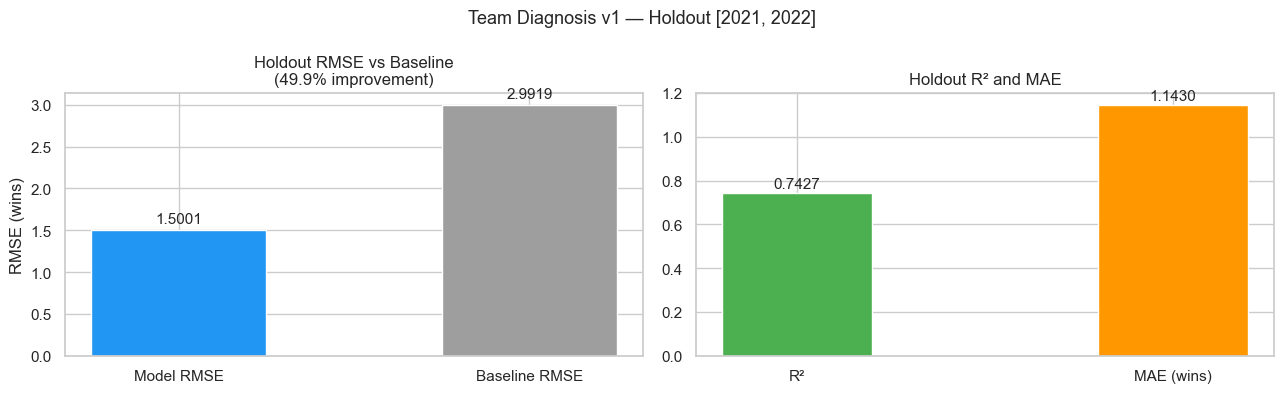

Saved → C:\Users\Areen\Python\.venv\nfl-model-platform\notebook\outputs\team_diagnosis_holdout_metrics.png


In [9]:
# ── Cross-version metrics table ───────────────────────────────────────────────
METRIC_COLS = ["holdout_r2", "holdout_rmse", "holdout_mae", "baseline_rmse",
               "beat_baseline", "train_rows", "holdout_rows", "ridge_alpha"]

rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    row = {"version": meta.get("version", run.name)}
    for k in METRIC_COLS:
        row[k] = meta.get(k)
    rows.append(row)

compare_df = pd.DataFrame(rows).set_index("version")
display(compare_df)

# ── Bar chart: key metrics ────────────────────────────────────────────────────
meta = load_metadata(selected_artifact_dir) or {}
metrics = {
    "R²":           meta.get("holdout_r2"),
    "RMSE": meta.get("holdout_rmse"),
    "MAE":          meta.get("holdout_mae"),
    "Baseline RMSE":meta.get("baseline_rmse"),
}
colors = ["#2196F3", "#FF5722", "#FF9800", "#9E9E9E"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: RMSE vs baseline
ax = axes[0]
rmse     = meta.get("holdout_rmse", 0)
baseline = meta.get("baseline_rmse", 0)
bars = ax.bar(["Model RMSE", "Baseline RMSE"], [rmse, baseline],
              color=["#2196F3", "#9E9E9E"], width=0.5)
for bar, val in zip(bars, [rmse, baseline]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
pct = (1 - rmse / baseline) * 100 if baseline else 0
ax.set_title(f"Holdout RMSE vs Baseline\n({pct:.1f}% improvement)")
ax.set_ylabel("RMSE (wins)")

# Right: R², MAE
ax = axes[1]
vals   = [meta.get("holdout_r2", 0), meta.get("holdout_mae", 0)]
labels = ["R²", "MAE (wins)"]
bars = ax.bar(labels, vals, color=["#4CAF50", "#FF9800"], width=0.4)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.set_title("Holdout R² and MAE")

fig.suptitle(
    f"Team Diagnosis {meta.get('version', '')} — "
    f"Holdout {meta.get('holdout_season_range')}",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "team_diagnosis_holdout_metrics.png", bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_holdout_metrics.png'}")

## SHAP Feature Importance (Expected Wins)

c:\Users\Areen\Python\.venv\nfl-model-platform\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Areen\Python\.venv\nfl-model-platform\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RidgeCV from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


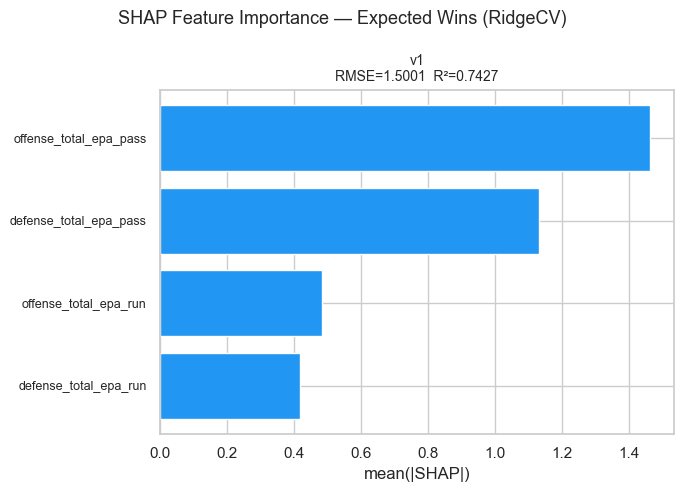

Saved → C:\Users\Areen\Python\.venv\nfl-model-platform\notebook\outputs\team_diagnosis_shap.png


In [10]:
import shap

fig, axes = plt.subplots(1, len(artifact_dirs), figsize=(7 * len(artifact_dirs), 5))
if len(artifact_dirs) == 1:
    axes = [axes]

for ax, run in zip(axes, artifact_dirs):
    meta     = load_metadata(run) or {}
    model    = load_ridge_model(run)
    feat_df  = load_feature_data(run)
    shap_df  = load_shap_values(run)
    version  = meta.get("version", run.name)
    ew_feats = meta.get("ew_features", meta.get("feature_names", []))

    if shap_df is not None and not shap_df.empty:
        # Pre-computed SHAP from artifact
        mean_abs = shap_df[ew_feats].abs().mean() if all(c in shap_df.columns for c in ew_feats) else shap_df.abs().mean()
        fi = mean_abs.sort_values().to_frame("mean_|SHAP|")
    elif model is not None and feat_df is not None:
        # Compute on the fly via LinearExplainer
        feat_cols = [c for c in ew_feats if c in feat_df.columns]
        X = feat_df[feat_cols].fillna(0).astype(float)
        explainer = shap.LinearExplainer(model, X)
        sv = explainer.shap_values(X)
        mean_abs = np.abs(sv).mean(axis=0)
        fi = pd.DataFrame({"feature": feat_cols, "mean_|SHAP|": mean_abs}).set_index("feature").sort_values("mean_|SHAP|")
    else:
        ax.set_title(f"{version} — no model/features")
        continue

    ax.barh(fi.index, fi["mean_|SHAP|"], color="#2196F3")
    ax.set_title(
        f"{version}\nRMSE={meta.get('holdout_rmse','?')}  R²={meta.get('holdout_r2','?')}",
        fontsize=10
    )
    ax.set_xlabel("mean(|SHAP|)")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("SHAP Feature Importance — Expected Wins (RidgeCV)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "team_diagnosis_shap.png", bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_shap.png'}")

## Train vs Holdout Distribution

Columns: ['team', 'season', 'offense_total_epa_pass', 'offense_total_epa_run', 'defense_total_epa_pass', 'defense_total_epa_run', 'offense_ave_epa_pass', 'offense_success_rate_pass', 'offense_ave_yards_gained_pass', 'offense_ave_wpa_pass', 'offense_n_interceptions', 'offense_n_plays_pass', 'offense_ave_epa_run', 'offense_success_rate_run', 'offense_ave_yards_gained_run', 'offense_ave_wpa_run', 'offense_n_fumbles_lost_run', 'offense_n_plays_run', 'defense_ave_epa_pass', 'defense_success_rate_pass', 'defense_ave_yards_gained_pass', 'defense_ave_wpa_pass', 'defense_n_interceptions', 'defense_n_plays_pass', 'defense_ave_epa_run', 'defense_success_rate_run', 'defense_ave_yards_gained_run', 'defense_ave_wpa_run', 'defense_n_fumbles_lost_pass', 'defense_n_fumbles_lost_run', 'offense_n_fumbles_lost_pass', 'wins', 'artifact_dir']

Train    : 701 rows  (1999–2020)
Holdout  : 0 rows  (2021–2020)


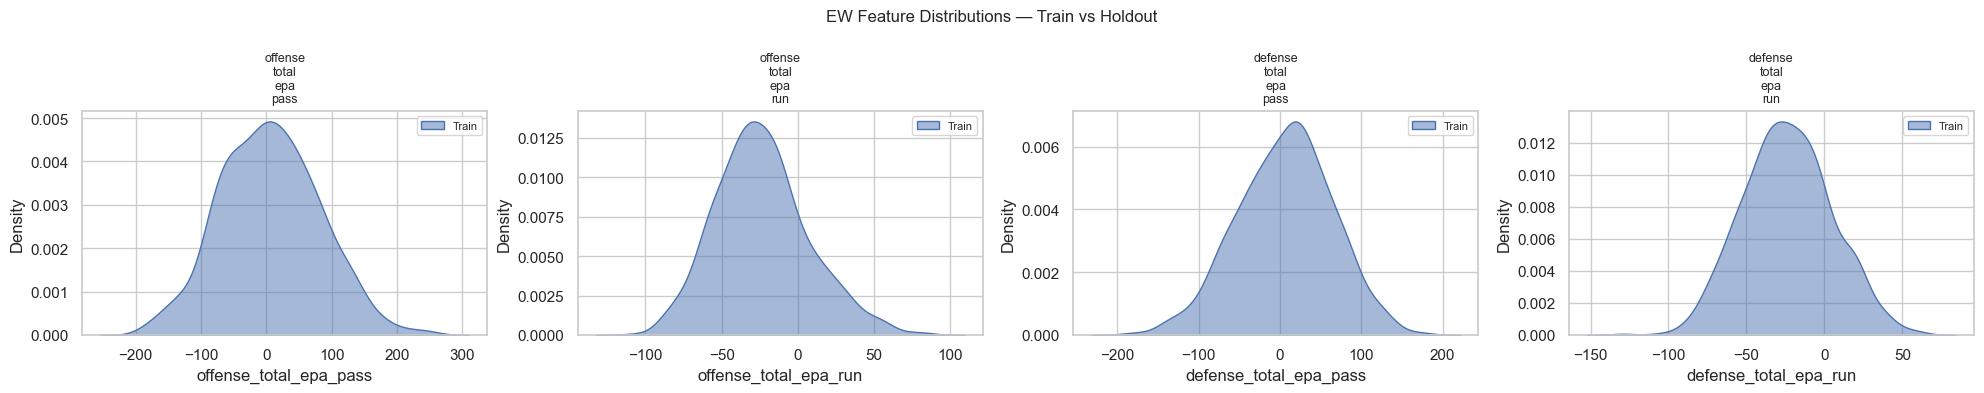

Saved → C:\Users\Areen\Python\.venv\nfl-model-platform\notebook\outputs\team_diagnosis_feature_distributions.png


In [11]:
feat_df = load_feature_data(selected_artifact_dir)
meta    = load_metadata(selected_artifact_dir) or {}

target_col  = "wins"   # adjust if stored under a different column name
season_col  = "season"
ew_feats    = meta.get("ew_features", meta.get("feature_names", []))

if feat_df is not None:
    feat_df = feat_df.reset_index()
    print("Columns:", feat_df.columns.tolist())

    holdout_start = meta.get("holdout_season_range", [2021, 2022])[0]
    train_df   = feat_df[feat_df[season_col] <  holdout_start] if season_col in feat_df.columns else feat_df
    holdout_df = feat_df[feat_df[season_col] >= holdout_start] if season_col in feat_df.columns else pd.DataFrame()

    print(f"\nTrain    : {len(train_df)} rows  "
          f"({feat_df[season_col].min() if season_col in feat_df.columns else '?'}–{holdout_start-1})")
    print(f"Holdout  : {len(holdout_df)} rows  "
          f"({holdout_start}–{feat_df[season_col].max() if season_col in feat_df.columns else '?'})")

    # Feature distributions: train vs holdout
    plot_feats = [c for c in ew_feats if c in feat_df.columns]
    fig, axes = plt.subplots(1, len(plot_feats), figsize=(5 * len(plot_feats), 4))
    if len(plot_feats) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_feats):
        if not holdout_df.empty:
            sns.kdeplot(data=train_df,   x=col, label="Train",   fill=True, alpha=0.5, ax=ax)
            sns.kdeplot(data=holdout_df, x=col, label="Holdout", fill=True, alpha=0.5, ax=ax)
        else:
            sns.kdeplot(data=train_df, x=col, label="Train", fill=True, alpha=0.5, ax=ax)
        ax.set_title(col.replace("_", "\n"), fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle("EW Feature Distributions — Train vs Holdout", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "team_diagnosis_feature_distributions.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_feature_distributions.png'}")
else:
    print("No feature data available.")

## Unit Score Correlations
Inspect how the 28 unit stat columns relate to each other and to the EW features.

In [ ]:
feat_df = load_feature_data(selected_artifact_dir)
meta    = load_metadata(selected_artifact_dir) or {}
all_features = meta.get("all_feature_cols", [])
ew_feats     = meta.get("ew_features", meta.get("feature_names", []))

if feat_df is not None and all_features:
    feat_df = feat_df.reset_index()
    plot_cols = [c for c in all_features if c in feat_df.columns]

    corr = feat_df[plot_cols].corr()

    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, cmap="RdYlGn", center=0,
        annot=True, fmt=".2f", annot_kws={"size": 6},
        linewidths=0.3, square=True,
    )
    plt.title("Unit Stat Correlation Matrix", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "team_diagnosis_correlation_matrix.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_correlation_matrix.png'}")

    # Correlation of each unit stat with each EW feature
    ew_cols = [c for c in ew_feats if c in feat_df.columns]
    unit_cols = [c for c in plot_cols if c not in ew_cols]
    if ew_cols and unit_cols:
        cross_corr = feat_df[unit_cols + ew_cols].corr().loc[unit_cols, ew_cols]
        print("\nUnit stats × EW features correlation:")
        display(
            cross_corr.style
            .background_gradient(cmap="RdYlGn", axis=None, vmin=-1, vmax=1)
            .format("{:.3f}")
        )
else:
    print("No feature data or all_feature_cols not in metadata.")

## CV vs Holdout Gap Investigation

In [ ]:
feat_df = load_feature_data(selected_artifact_dir)
meta    = load_metadata(selected_artifact_dir) or {}
season_col   = "season"
ew_feats     = meta.get("ew_features", meta.get("feature_names", []))
holdout_start = meta.get("holdout_season_range", [2021, 2022])[0]

if feat_df is not None and season_col in feat_df.reset_index().columns:
    feat_df = feat_df.reset_index()
    train_df   = feat_df[feat_df[season_col] <  holdout_start]
    holdout_df = feat_df[feat_df[season_col] >= holdout_start]

    print("=== Split summary ===")
    for name, df in [("Train  ", train_df), ("Holdout", holdout_df)]:
        yrs = f"{df[season_col].min()}–{df[season_col].max()}" if len(df) else "—"
        print(f"  {name}  ({yrs})  n={len(df):>4}")

    # Per-season stats for each EW feature
    plot_feats = [c for c in ew_feats if c in feat_df.columns]
    fig, axes = plt.subplots(len(plot_feats), 1,
                             figsize=(14, 3 * len(plot_feats)), sharex=True)
    if len(plot_feats) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_feats):
        by_season = feat_df.groupby(season_col)[col].mean()
        colors = ["#FF9800" if s >= holdout_start else "#2196F3" for s in by_season.index]
        ax.bar(by_season.index, by_season.values, color=colors, width=0.7)
        ax.axvline(holdout_start - 0.5, color="red", linestyle="--", linewidth=1)
        ax.set_ylabel(col.replace("_", "\n"), fontsize=8)
        ax.tick_params(axis="x", labelsize=8)

    axes[-1].set_xlabel("Season")
    plt.suptitle(
        f"League-average EW features by season\n(orange = holdout {holdout_start}+)",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "team_diagnosis_season_trends.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_season_trends.png'}")

    # Overlap check
    train_seasons   = set(train_df[season_col].unique())
    holdout_seasons = set(holdout_df[season_col].unique())
    overlap = train_seasons & holdout_seasons
    print("\n=== Season overlap check ===")
    if overlap:
        print(f"  WARNING — overlapping seasons: {sorted(overlap)}")
    else:
        print(f"  Clean split.")
        print(f"  Train seasons   : {sorted(train_seasons)}")
        print(f"  Holdout seasons : {sorted(holdout_seasons)}")
else:
    print("No feature data or season column not found.")

## Ridge Coefficient Inspection
The RidgeCV model is fully linear — coefficients are the complete picture of how each EPA feature drives expected wins.

In [ ]:
model = load_ridge_model(selected_artifact_dir)
meta  = load_metadata(selected_artifact_dir) or {}
ew_feats = meta.get("ew_features", meta.get("feature_names", []))

if model is not None and hasattr(model, "coef_"):
    coefs = pd.Series(model.coef_, index=ew_feats).sort_values()

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#F44336" if v < 0 else "#2196F3" for v in coefs]
    bars = ax.barh(coefs.index, coefs.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars, coefs.values):
        ax.text(
            val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9
        )
    ax.set_title(
        f"RidgeCV Coefficients (alpha={meta.get('ridge_alpha')})\n"
        f"Intercept={model.intercept_:.3f}"
    )
    ax.set_xlabel("Coefficient (wins per unit EPA)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "team_diagnosis_ridge_coefs.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_ridge_coefs.png'}")

    print("\nCoefficients:")
    display(coefs.to_frame("coefficient").style.bar(color=["#F44336", "#2196F3"], align="zero"))
else:
    print("Ridge model not available or has no coef_ attribute.")

## All-Version Comparison

In [ ]:
rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    rows.append({
        "version":       meta.get("version", run.name),
        "holdout_r2":    meta.get("holdout_r2"),
        "holdout_rmse":  meta.get("holdout_rmse"),
        "holdout_mae":   meta.get("holdout_mae"),
        "baseline_rmse": meta.get("baseline_rmse"),
        "train_rows":    meta.get("train_rows"),
        "holdout_rows":  meta.get("holdout_rows"),
        "n_ew_features": len(meta.get("ew_features", [])),
        "n_unit_features": len(meta.get("all_feature_cols", [])),
        "ridge_alpha":   meta.get("ridge_alpha"),
    })

prog = pd.DataFrame(rows)

if len(prog) > 1:
    v1_rmse = prog.loc[prog["version"] == "v1", "holdout_rmse"].values[0]
    prog["delta_rmse_vs_v1"]  = prog["holdout_rmse"] - v1_rmse

baseline_rmse = prog["baseline_rmse"].iloc[0]
prog["pct_beat_baseline"] = (1 - prog["holdout_rmse"] / baseline_rmse) * 100

display_cols = ["version", "holdout_r2", "holdout_rmse", "holdout_mae",
                "pct_beat_baseline", "n_ew_features", "n_unit_features", "ridge_alpha"]
if "delta_rmse_vs_v1" in prog.columns:
    display_cols.insert(4, "delta_rmse_vs_v1")

fmt = {
    "holdout_r2":         "{:.4f}",
    "holdout_rmse":       "{:.4f}",
    "holdout_mae":        "{:.4f}",
    "pct_beat_baseline":  "{:.1f}%",
}
if "delta_rmse_vs_v1" in prog.columns:
    fmt["delta_rmse_vs_v1"] = "{:+.4f}"

styled = (
    prog[display_cols]
    .style
    .format(fmt)
    .background_gradient(subset=["holdout_rmse", "holdout_mae"], cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["holdout_r2", "pct_beat_baseline"], cmap="RdYlGn", axis=0)
)
display(styled)

# ── Progression chart ─────────────────────────────────────────────────────────
if len(prog) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    bars = ax.bar(prog["version"], prog["holdout_rmse"], color="#2196F3", width=0.5)
    ax.axhline(baseline_rmse, color="red", linestyle="--", linewidth=1,
               label=f"baseline ({baseline_rmse:.2f})")
    for bar, val in zip(bars, prog["holdout_rmse"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title("Holdout RMSE by version")
    ax.set_ylabel("RMSE (wins)")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(prog["version"], prog["holdout_r2"], marker="o", color="#4CAF50", linewidth=2)
    for _, row in prog.iterrows():
        ax.annotate(f"{row['holdout_r2']:.3f}", (row["version"], row["holdout_r2"]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.set_title("R² progression")
    ax.set_ylabel("R²")

    ax = axes[2]
    bars = ax.bar(prog["version"], prog["pct_beat_baseline"], color="#FF9800", width=0.5)
    for bar, val in zip(bars, prog["pct_beat_baseline"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title("% improvement over baseline")
    ax.set_ylabel("% RMSE reduction")

    plt.suptitle("All-version comparison — Team Diagnosis", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "team_diagnosis_version_comparison.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'team_diagnosis_version_comparison.png'}")
else:
    print("Only one version found — skipping progression chart.")